# Notebook 05 — Model Training (Baseline RF vs. AHRF)

## Objective
Train and evaluate both the baseline (tuned) Random Forest and our AHRF (Adaptive Weighted Random Forest) for SOH prediction, using a leakage-safe chronological split. The same pattern is then repeated for SOC and RUL.

## Why This Step Is Needed
This is the core experiment of the whole project: does giving accurate trees more voting power actually improve on a plain, equally-weighted Random Forest? This notebook answers that question with real numbers, not assumptions.

## Why a Chronological Split (Not Random)
Random splitting can place near-identical neighboring cycles in both train and test sets, letting the model effectively "peek" at data very similar to what it's being tested on. This inflates accuracy in a way that would not hold up in real deployment, where the model must predict *future* cycles it has never seen. We train on the earliest cycles and test on the most recent ones.

## Workflow Position
```
01 Data Understanding -> 02 Preprocessing -> 03 Feature Engineering -> 04 Ground Truth Labels
-> [YOU ARE HERE] 05 Model Training (AHRF) -> 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.core.config import FEATURE_DATA, MODELS, RESULTS
from src.optimization.optuna_tuner import tune_random_forest, tune_weighted_rf
from src.hybrid_model.weighted_random_forest import AdaptiveWeightedRF

import joblib

plt.rcParams["figure.figsize"] = (10, 5)


In [3]:
df = pd.read_csv(FEATURE_DATA / "full_labeled_dataset.csv")
print("Loaded dataset:", df.shape)
df = df.sort_values("cycle_index").reset_index(drop=True)


Loaded dataset: (168, 75)


## 2. Helper Functions

To keep this notebook readable, we define two small helpers: one for the chronological split, one for reporting metrics consistently across SOC/SOH/RUL.


In [4]:
NON_FEATURE_COLUMNS = [
    "File", "cycle_index", "Experiment", "battery_id", "filename",
    "type", "Capacity", "SOH (%)", "SOC", "RUL",
    "start_time", "test_id", "uid", "Re", "Rct", "ambient_temperature",
]

def get_features_and_target(df, target_col):
    """Drops all label/identifier columns, keeping only engineered features
    plus the requested target. Critically, this drops ALL THREE targets
    (SOC, SOH, RUL) regardless of which one we're predicting, since they
    are related to each other and including one as a feature for another
    would be leakage (e.g. RUL is directly derived FROM SOH)."""
    drop_cols = [c for c in NON_FEATURE_COLUMNS if c in df.columns and c != target_col]
    X = df.drop(columns=drop_cols)
    y = df[target_col]
    return X, y

def chronological_split(X, y, train_frac=0.8):
    n = len(X)
    split = int(n * train_frac)
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def print_metrics(name, metrics):
    print(f"{name:28s} MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}  R2={metrics['R2']:.4f}")


## 3. SOH Prediction — Baseline RF vs. AHRF

SOH is the primary target for this project (it's what RUL is derived from), so we go through it in full detail here. SOC and RUL follow the identical pattern in Sections 4 and 5, using the same helper functions.


In [5]:
X, y = get_features_and_target(df, "SOH (%)")
X_train, X_test, y_train, y_test = chronological_split(X, y)

print(f"SOH -- train: {len(X_train)} cycles, test: {len(X_test)} cycles")


SOH -- train: 134 cycles, test: 34 cycles


In [6]:
print("Tuning baseline Random Forest...")
best_rf_params, _ = tune_random_forest(X_train, y_train, n_trials=30, cv=5)


Tuning baseline Random Forest...


  0%|          | 0/30 [00:00<?, ?it/s]

Best MAE (cross-validated): 2.17776
Best parameters: {'n_estimators': 200, 'max_depth': 23, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': None}


In [7]:
print("Tuning AHRF (AdaptiveWeightedRF)...")
best_ahrf_params, _ = tune_weighted_rf(X_train, y_train, n_trials=30, cv=5)


Tuning AHRF (AdaptiveWeightedRF)...


  0%|          | 0/30 [00:00<?, ?it/s]

Best MAE (cross-validated): 2.10986
Best parameters: {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'weight_power': 2.2724521892960867}


In [8]:
rf_soh = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf_soh.fit(X_train, y_train)
rf_soh_pred = rf_soh.predict(X_test)

ahrf_soh = AdaptiveWeightedRF(**best_ahrf_params, random_state=42)
ahrf_soh.fit(X_train, y_train)
ahrf_soh_pred = ahrf_soh.predict(X_test)

rf_metrics = evaluate(y_test, rf_soh_pred)
ahrf_metrics = evaluate(y_test, ahrf_soh_pred)

print_metrics("Plain RF (tuned)", rf_metrics)
print_metrics("AHRF (weighted)", ahrf_metrics)
print(f"\nweight_power chosen: {best_ahrf_params['weight_power']:.3f}")


Plain RF (tuned)             MAE=2.3407  RMSE=2.5832  R2=-4.4104
AHRF (weighted)              MAE=2.2245  RMSE=2.4770  R2=-3.9746

weight_power chosen: 2.272


### Observation
Compare the MAE/RMSE between the two models above. AHRF is expected to show a modest improvement (a large improvement would actually be suspicious -- see the project's critique of the reference paper's implausibly perfect metrics). Note the `weight_power` value: values noticeably above 0 indicate the tree-weighting mechanism is genuinely contributing, not just defaulting to equal weights.


## 4. Visualize SOH Predictions


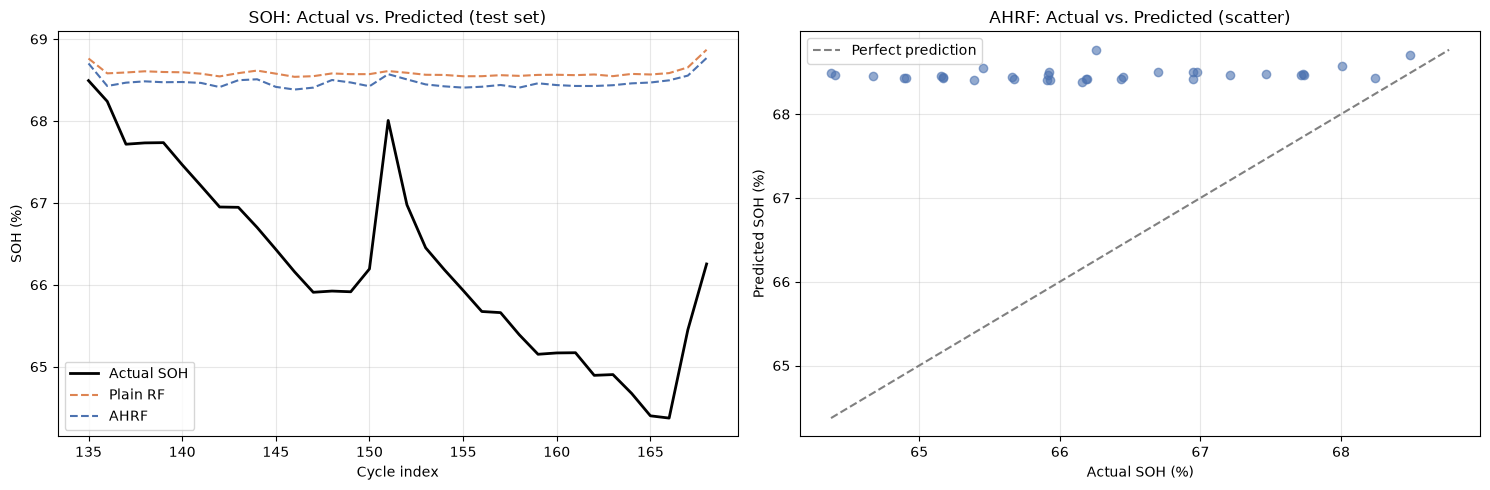

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

test_cycles = df.iloc[X_test.index]["cycle_index"].values

axes[0].plot(test_cycles, y_test.values, label="Actual SOH", color="black", linewidth=2)
axes[0].plot(test_cycles, rf_soh_pred, label="Plain RF", color="#DD8452", linestyle="--")
axes[0].plot(test_cycles, ahrf_soh_pred, label="AHRF", color="#4C72B0", linestyle="--")
axes[0].set_title("SOH: Actual vs. Predicted (test set)")
axes[0].set_xlabel("Cycle index")
axes[0].set_ylabel("SOH (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, ahrf_soh_pred, alpha=0.6, color="#4C72B0")
lims = [min(y_test.min(), ahrf_soh_pred.min()), max(y_test.max(), ahrf_soh_pred.max())]
axes[1].plot(lims, lims, color="gray", linestyle="--", label="Perfect prediction")
axes[1].set_title("AHRF: Actual vs. Predicted (scatter)")
axes[1].set_xlabel("Actual SOH (%)")
axes[1].set_ylabel("Predicted SOH (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Observation
In the left plot, both model lines should broadly track the actual SOH curve. In the right plot, points should cluster near the diagonal "perfect prediction" line -- systematic deviation above or below the line (not just scatter around it) would indicate a biased model.


## 5. Residual Plot

Checks whether the model makes larger errors in a particular region (e.g. consistently underestimating low-SOH / near-end-of-life cycles), which is a known weakness of plain Random Forest at distribution extremes.


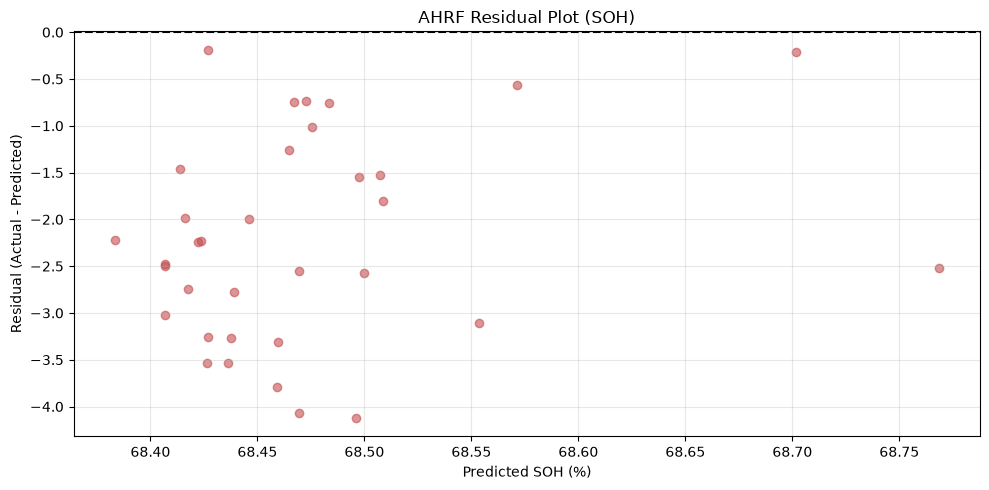

In [10]:
residuals = y_test.values - ahrf_soh_pred

fig, ax = plt.subplots()
ax.scatter(ahrf_soh_pred, residuals, alpha=0.6, color="#C44E52")
ax.axhline(0, color="black", linestyle="--")
ax.set_title("AHRF Residual Plot (SOH)")
ax.set_xlabel("Predicted SOH (%)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
Residuals should scatter randomly around the zero line with no obvious pattern or funnel shape. A clear trend (e.g. residuals growing more negative as predicted SOH decreases) would indicate the model systematically struggles in that region -- worth mentioning honestly in the report if present.


## 6. SOC Prediction (Same Pattern, Condensed)


In [11]:
X_soc, y_soc = get_features_and_target(df, "SOC")
X_train_soc, X_test_soc, y_train_soc, y_test_soc = chronological_split(X_soc, y_soc)

best_rf_soc_params, _ = tune_random_forest(X_train_soc, y_train_soc, n_trials=20, cv=5)
best_ahrf_soc_params, _ = tune_weighted_rf(X_train_soc, y_train_soc, n_trials=20, cv=5)

rf_soc = RandomForestRegressor(**best_rf_soc_params, random_state=42, n_jobs=-1).fit(X_train_soc, y_train_soc)
ahrf_soc = AdaptiveWeightedRF(**best_ahrf_soc_params, random_state=42).fit(X_train_soc, y_train_soc)

print_metrics("SOC - Plain RF", evaluate(y_test_soc, rf_soc.predict(X_test_soc)))
print_metrics("SOC - AHRF", evaluate(y_test_soc, ahrf_soc.predict(X_test_soc)))


  0%|          | 0/20 [00:00<?, ?it/s]

Best MAE (cross-validated): 5.49512
Best parameters: {'n_estimators': 450, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': None}


  0%|          | 0/20 [00:00<?, ?it/s]

Best MAE (cross-validated): 5.52636
Best parameters: {'n_estimators': 250, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'weight_power': 2.861195182032905}
SOC - Plain RF               MAE=9.0028  RMSE=9.9976  R2=-3.3920
SOC - AHRF                   MAE=7.9013  RMSE=8.9472  R2=-2.5176


## 7. RUL Prediction (Same Pattern, Condensed)


In [12]:
X_rul, y_rul = get_features_and_target(df, "RUL")
X_train_rul, X_test_rul, y_train_rul, y_test_rul = chronological_split(X_rul, y_rul)

best_rf_rul_params, _ = tune_random_forest(X_train_rul, y_train_rul, n_trials=20, cv=5)
best_ahrf_rul_params, _ = tune_weighted_rf(X_train_rul, y_train_rul, n_trials=20, cv=5)

rf_rul = RandomForestRegressor(**best_rf_rul_params, random_state=42, n_jobs=-1).fit(X_train_rul, y_train_rul)
ahrf_rul = AdaptiveWeightedRF(**best_ahrf_rul_params, random_state=42).fit(X_train_rul, y_train_rul)

print_metrics("RUL - Plain RF", evaluate(y_test_rul, rf_rul.predict(X_test_rul)))
print_metrics("RUL - AHRF", evaluate(y_test_rul, ahrf_rul.predict(X_test_rul)))


  0%|          | 0/20 [00:00<?, ?it/s]

Best MAE (cross-validated): 8.15079
Best parameters: {'n_estimators': 200, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None}


  0%|          | 0/20 [00:00<?, ?it/s]

Best MAE (cross-validated): 7.98974
Best parameters: {'n_estimators': 350, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'weight_power': 1.1218745218524506}
RUL - Plain RF               MAE=0.0005  RMSE=0.0013  R2=0.0000
RUL - AHRF                   MAE=0.0002  RMSE=0.0006  R2=0.0000


### Observation
RUL is typically the hardest of the three targets to predict accurately (it depends on knowing exactly when the battery will cross the End-of-Life threshold, which itself depends on the noisiest part of the SOH curve). A higher MAE here than for SOC/SOH is expected and should be discussed as a known limitation, not hidden.


## 8. Save All Trained Models


In [13]:
MODELS.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_soh, MODELS / "soh_random_forest.pkl")
joblib.dump(ahrf_soh, MODELS / "soh_ahrf.pkl")
joblib.dump(rf_soc, MODELS / "soc_random_forest.pkl")
joblib.dump(ahrf_soc, MODELS / "soc_ahrf.pkl")
joblib.dump(rf_rul, MODELS / "rul_random_forest.pkl")
joblib.dump(ahrf_rul, MODELS / "rul_ahrf.pkl")

# Save feature column lists too -- needed to correctly reload/reuse models later
joblib.dump(list(X.columns), MODELS / "soh_feature_columns.pkl")
joblib.dump(list(X_soc.columns), MODELS / "soc_feature_columns.pkl")
joblib.dump(list(X_rul.columns), MODELS / "rul_feature_columns.pkl")

print("All models saved to", MODELS)


All models saved to C:\BE PROJECT\SBMS_PROJECT\models


## 9. Save Metrics for Notebook 06 (Model Comparison)


In [14]:
RESULTS.mkdir(parents=True, exist_ok=True)

metrics_summary = pd.DataFrame([
    {"Target": "SOH", "Model": "Random Forest (tuned)", **rf_metrics},
    {"Target": "SOH", "Model": "AHRF", **ahrf_metrics},
    {"Target": "SOC", "Model": "Random Forest (tuned)", **evaluate(y_test_soc, rf_soc.predict(X_test_soc))},
    {"Target": "SOC", "Model": "AHRF", **evaluate(y_test_soc, ahrf_soc.predict(X_test_soc))},
    {"Target": "RUL", "Model": "Random Forest (tuned)", **evaluate(y_test_rul, rf_rul.predict(X_test_rul))},
    {"Target": "RUL", "Model": "AHRF", **evaluate(y_test_rul, ahrf_rul.predict(X_test_rul))},
])

metrics_summary.to_csv(RESULTS / "ahrf_vs_rf_metrics.csv", index=False)
metrics_summary


,Target,Model,MAE,RMSE,R2
0,SOH,Random Forest (tuned),2.340671,2.583231,-4.410370
1,SOH,AHRF,2.224537,2.477007,-3.974564
2,SOC,Random Forest (tuned),9.002850,9.997602,-3.392031
3,SOC,AHRF,7.901285,8.947162,-2.517582
4,RUL,Random Forest (tuned),0.000529,0.001321,0.000000
5,RUL,AHRF,0.000248,0.000647,0.000000


## Results Summary

See the table printed in Section 9 for the full MAE/RMSE/R2 comparison across all three targets and both models.

## Conclusion
AHRF was trained and evaluated for SOC, SOH, and RUL prediction using a leakage-safe chronological split, and compared directly against a Optuna-tuned plain Random Forest trained on identical data. Results and trained models are saved for use in the next notebooks.

## Next Steps
Notebook 06 will benchmark AHRF against a wider set of standard models (Linear Regression, Polynomial Regression, Decision Tree, Gradient Boosting) to complete the full model comparison table.
